# SOBP y perfil radial — sin atenuador

Este notebook usa `bragg_pouch_zsinat.out` y `bragg_pouch_rsinat.out`.

Si el notebook está dentro de `sin_atenuador`, encuentra automáticamente la carpeta `out`. También funciona si está dentro de una subcarpeta `analisis`.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

if Path("out").exists():
    OUT = Path("out")
elif Path("../out").exists():
    OUT = Path("../out")
else:
    raise FileNotFoundError("No encuentro la carpeta out")

archivo_z = OUT / "bragg_pouch_zsinat.out"
archivo_r = OUT / "bragg_pouch_rsinat.out"

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 9
})


In [2]:
def leer_tdeposit_1d(archivo, eje):
    lower = []
    upper = []
    dosis = []
    error = []
    leyendo = False

    with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            texto = linea.strip()

            if texto.startswith(f"#  {eje}-lower"):
                leyendo = True
                continue

            if leyendo:
                partes = texto.split()

                if len(partes) < 4:
                    if lower:
                        break
                    continue

                try:
                    a, b, d, e = map(float, partes[:4])
                except ValueError:
                    if lower:
                        break
                    continue

                lower.append(a)
                upper.append(b)
                dosis.append(d)
                error.append(e)

    lower = np.array(lower)
    upper = np.array(upper)
    dosis = np.array(dosis)
    error = np.array(error)
    centro = 0.5 * (lower + upper)

    return centro, dosis, error

z, dosis_z, err_z = leer_tdeposit_1d(archivo_z, "z")
r, dosis_r, err_r = leer_tdeposit_1d(archivo_r, "r")

print(f"Puntos en z: {len(z)}")
print(f"Puntos en r: {len(r)}")


Puntos en z: 300
Puntos en r: 60


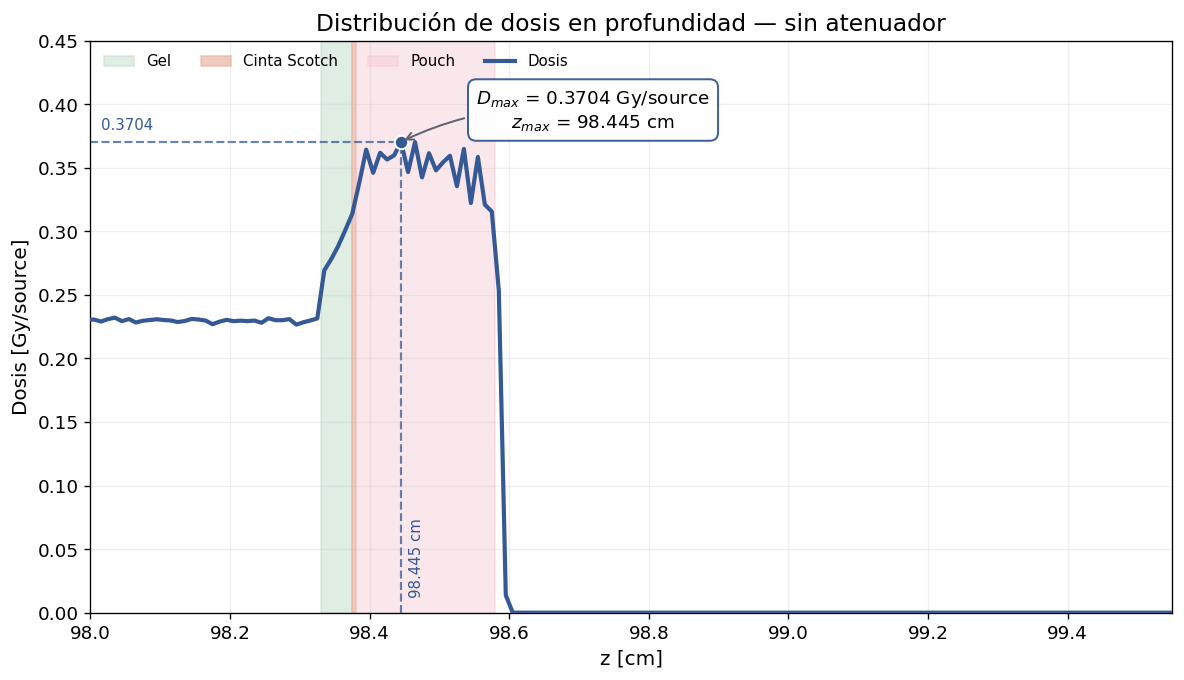

In [12]:
gel = (98.330, 98.375)
cinta = (98.375, 98.380)
pouch = (98.380, 98.580)

error_abs_z = dosis_z * err_z

i_pico = np.argmax(dosis_z)
z_pico = z[i_pico]
dosis_pico = dosis_z[i_pico]

fig, ax = plt.subplots(figsize=(10, 5.8))

ax.axvspan(*gel, color="#b8d8c0", alpha=0.45, label="Gel")
ax.axvspan(*cinta, color="#e9b6a5", alpha=0.70, label="Cinta Scotch")
ax.axvspan(*pouch, color="#f3c5cf", alpha=0.40, label="Pouch")

ax.plot(
    z,
    dosis_z,
    color="#345995",
    linewidth=2.5,
    label="Dosis",
    zorder=3
)

ax.fill_between(
    z,
    np.maximum(dosis_z - error_abs_z, 0),
    dosis_z + error_abs_z,
    color="#345995",
    alpha=0.10,
    linewidth=0,
    zorder=2
)

ax.scatter(
    z_pico,
    dosis_pico,
    s=65,
    color="#345995",
    edgecolor="white",
    linewidth=1.2,
    zorder=5
)

ax.vlines(
    z_pico,
    0,
    dosis_pico,
    color="#345995",
    linestyle="--",
    linewidth=1.3,
    alpha=0.75,
    zorder=1
)

ax.hlines(
    dosis_pico,
    98.0,
    z_pico,
    color="#345995",
    linestyle="--",
    linewidth=1.3,
    alpha=0.75,
    zorder=1
)

ax.annotate(
    f"$D_{{max}}$ = {dosis_pico:.4f} Gy/source\n"
    f"$z_{{max}}$ = {z_pico:.3f} cm",
    xy=(z_pico, dosis_pico),
    xytext=(98.72, 0.395),
    textcoords="data",
    ha="center",
    va="center",
    fontsize=11,
    arrowprops=dict(
        arrowstyle="->",
        color="#5b6470",
        linewidth=1.2,
        connectionstyle="arc3,rad=0.15"
    ),
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor="#345995",
        linewidth=1.2,
        alpha=0.95
    ),
    zorder=6
)

ax.text(
    z_pico + 0.012,
    0.012,
    f"{z_pico:.3f} cm",
    color="#345995",
    fontsize=9,
    rotation=90,
    va="bottom"
)

ax.text(
    98.015,
    dosis_pico + 0.007,
    f"{dosis_pico:.4f}",
    color="#345995",
    fontsize=9,
    va="bottom"
)

ax.set_xlabel("z [cm]")
ax.set_ylabel("Dosis [Gy/source]")
ax.set_title("Distribución de dosis en profundidad — sin atenuador")

ax.set_xlim(98.0, 99.55)
ax.set_ylim(0, 0.45)

ax.grid(alpha=0.20)

ax.legend(
    frameon=False,
    ncol=4,
    loc="upper left"
)

plt.tight_layout()
plt.show()

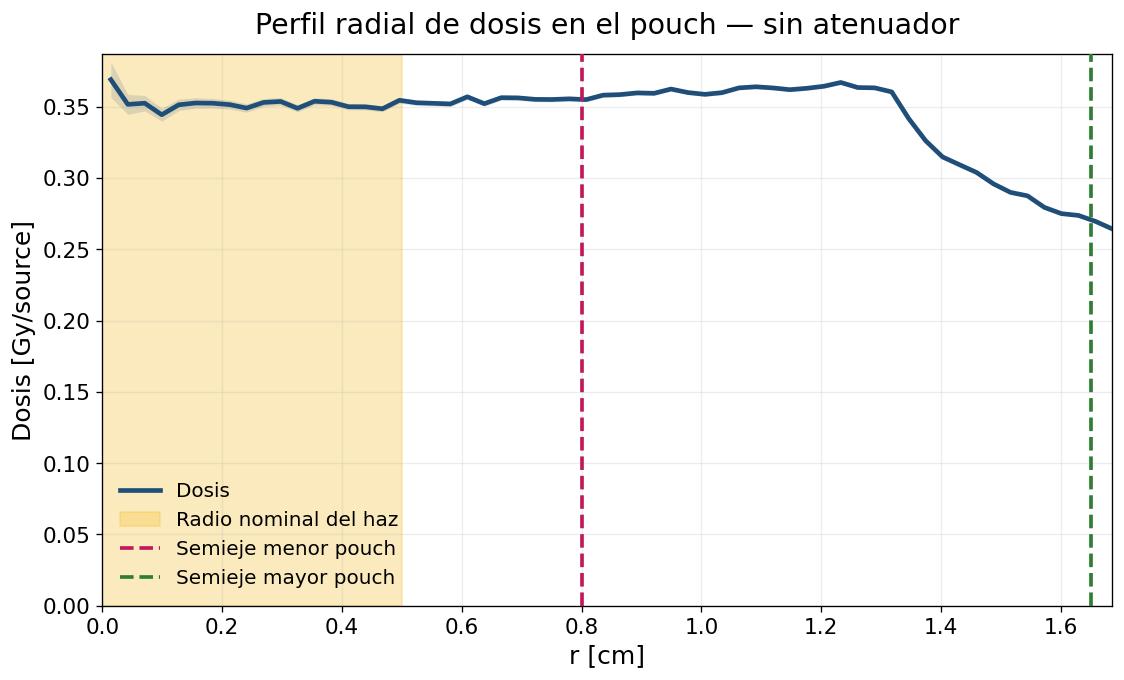

In [15]:
error_abs_r = dosis_r * err_r

fig, ax = plt.subplots(figsize=(9.5, 5.8))

# Curva de dosis
ax.plot(
    r,
    dosis_r,
    color="#1f4e79",
    linewidth=2.8,
    label="Dosis",
    zorder=3
)

# Error estadístico
ax.fill_between(
    r,
    np.maximum(dosis_r - error_abs_r, 0),
    dosis_r + error_abs_r,
    color="#1f4e79",
    alpha=0.15,
    linewidth=0,
    zorder=2
)

# Radio nominal del haz
ax.axvspan(
    0,
    0.5,
    color="#f4c542",
    alpha=0.35,
    label="Radio nominal del haz",
    zorder=1
)

# Semieje menor del pouch
ax.axvline(
    0.8,
    color="#c2185b",
    linestyle="--",
    linewidth=2.2,
    label="Semieje menor pouch",
    zorder=4
)

# Semieje mayor del pouch
ax.axvline(
    1.65,
    color="#2e7d32",
    linestyle="--",
    linewidth=2.2,
    label="Semieje mayor pouch",
    zorder=4
)

ax.set_xlabel(
    "r [cm]",
    fontsize=15
)

ax.set_ylabel(
    "Dosis [Gy/source]",
    fontsize=15
)

ax.set_title(
    "Perfil radial de dosis en el pouch — sin atenuador",
    fontsize=17,
    pad=12
)

ax.tick_params(
    axis="both",
    labelsize=13
)

ax.grid(
    alpha=0.22
)

ax.legend(
    frameon=False,
    fontsize=12,
    loc="lower left"
)

ax.set_xlim(0, r.max())
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()